# Smart Health Tracker - Random Forest Optimization

## Objective

In the previous notebook, Random Forest Regressor achieved the best performance among the evaluated models.

The objective of this notebook is to:

- Tune the Random Forest hyperparameters using GridSearchCV.
- Evaluate the tuned model using Cross Validation.
- Analyze feature importance.
- Save the best trained model for integration into the Smart Health Tracker application.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df=pd.read_csv("../data/health_logs.csv")

In [3]:
df.head()

,Date,Weight_kg,Calories,Protein_g,Carbohydrates_g,Fats_g,Fiber_g,Water_L,Sleep_hr,Workout_Min,Steps
0,2026-07-01,59.0,2350,140,300,65,25,3.0,7,60,8500
1,2026-07-02,59.2,2450,145,310,68,27,3.2,8,65,9100
2,2026-07-03,59.3,2550,150,320,70,28,3.5,8,70,9800
3,2026-07-04,59.5,2500,148,315,69,26,3.1,7,60,8900
4,2026-07-05,59.6,2650,155,330,72,30,3.6,8,75,10500


In [5]:
X=df[["Calories","Protein_g","Carbohydrates_g","Fats_g","Fiber_g","Water_L","Sleep_hr","Workout_Min","Steps"]]
y=df["Weight_kg"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
param_grid={
    "n_estimators":[10,50,100],
    "max_depth":[None,5,10]
}

In [11]:
grid=GridSearchCV(
estimator=RandomForestRegressor(random_state=42),
param_grid=param_grid,
cv=5,
scoring="neg_mean_absolute_error"
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ve

In [12]:
print("Best Parameters :", grid.best_params_)
print("Best MAE :", -grid.best_score_)

Best Parameters : {'max_depth': None, 'n_estimators': 50}
Best MAE : 0.2591999999999999


In [15]:
best_model=grid.best_estimator_
y_pred=grid.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.1920
MSE  : 0.0370
RMSE : 0.1924
R²   : 0.8777


In [19]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)
cv_mae = -cv_scores

print(cv_mae)
print(cv_mae.mean())
print(cv_mae.std())

[0.378 0.281 0.213 0.323 0.512]
0.34139999999999304
0.10091303186408329


In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Protein_g,0.516723
2,Carbohydrates_g,0.131771
0,Calories,0.089408
7,Workout_Min,0.072579
8,Steps,0.048904
3,Fats_g,0.048224
4,Fiber_g,0.042666
6,Sleep_hr,0.033297
5,Water_L,0.016428


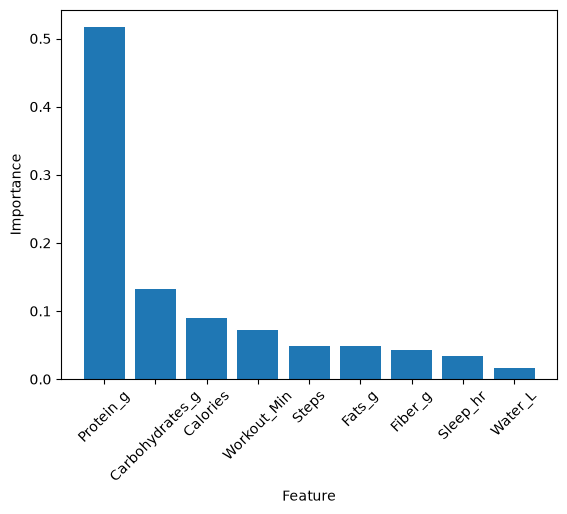

In [23]:
plt.bar(importance["Feature"],importance["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [24]:
joblib.dump(best_model,"../models/weight_predictor.pkl")
print("Model saved successfully")

Model saved successfully


# Conclusion

The Random Forest model was optimized using GridSearchCV to identify the best combination of hyperparameters.

The tuned model was evaluated using Cross Validation, which provided a more reliable estimate of its performance compared to a single train-test split.

Feature importance analysis showed which health-related variables contributed the most to weight prediction.

Finally, the optimized model was saved and integrated into the Smart Health Tracker application for real-time weight prediction.